In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import os

print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.copilot', '.docker', '.eclipse', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.local', '.matplotlib', '.ms-ad', '.p2', '.streamlit', '.vscode', '.vscode-shared', 'Algerian_forest_fires_cleaned_dataset.csv', 'Algerian_forest_fires_dataset_UPDATE.csv', 'anaconda3', 'anaconda_projects', 'analysis.ipynb', 'app', 'app.py', 'AppData', 'Application Data', 'chart1_price_distribution.png', 'chart2_correlation_heatmap.png', 'chart2_heatmap.png', 'chart3_actual_vs_predicted.png', 'chart4_feature_correlation.png', 'Contacts', 'Cookies', 'dimention_reduction_pipelines_project.ipynb', 'DockerFile', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'Favorites', 'HousePricePrediction_Pranavika', 'HousePricePrediction_Pranavika (2).zip', 'Housing.csv', 'import java.util.java', 'IntelGraphicsProfiles', 'LinearRegressionTg.ipynb', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'New folder', '

**LOAD THE DATASET**

In [3]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
##Display first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
## shape
print("Shape of Dataset:", df.shape)
print("Rows =", df.shape[0])
print("Columns =", df.shape[1])

Shape of Dataset: (545, 13)
Rows = 545
Columns = 13


In [6]:
##View column names
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
##Identify target and features
target = "price"

features = df.drop("price", axis=1).columns

print("Target Column:", target)
print("\nFeature Columns:")
print(features)

Target Column: price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [8]:
##Missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

no missing values

In [9]:
##info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


We have 7 categorical columns and 6 numerical columns

**DATA CLEANING**

In [10]:
##check duplicates
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


No duplicates

In [11]:
##no duplicated,but code to remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (545, 13)


In [12]:
##numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Columns:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

basement
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [15]:
##converting categorical columns using one hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [16]:
df_encoded = df_encoded.astype(int)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [17]:
df_encoded.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int32
 1   area                             545 non-null    int32
 2   bedrooms                         545 non-null    int32
 3   bathrooms                        545 non-null    int32
 4   stories                          545 non-null    int32
 5   parking                          545 non-null    int32
 6   mainroad_yes                     545 non-null    int32
 7   guestroom_yes                    545 non-null    int32
 8   basement_yes                     545 non-null    int32
 9   hotwaterheating_yes              545 non-null    int32
 10  airconditioning_yes              545 non-null    int32
 11  prefarea_yes                     545 non-null    int32
 12  furnishingstatus_semi-furnished  545 non-null    i

All columns are now numerical

In [18]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**DATA MODELING**

In [19]:
##dependent and independent 
X = df_encoded.drop('price', axis=1)

y = df_encoded['price']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (545, 13)
y Shape: (545,)


In [20]:
##train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (436, 13)
Testing Shape: (109, 13)


In [21]:
##Train linear regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [22]:
##making prediction
lr_pred = lr.predict(X_test)

print(lr_pred[:5])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


In [23]:
##Evalution
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153182


In [24]:
##Comparing actual vs predicted
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': lr_pred
})

comparison_df.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


In [25]:
##RandomForestRegression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [26]:
rf_pred = rf.predict(X_test)

print(rf_pred[:5])

[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [27]:
##Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


In [28]:
##model comparision
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [29]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [30]:
##Best model
best_model = comparison.loc[comparison['R2 Score'].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Linear Regression
MAE              970043.40392
RMSE           1324506.960091
R2 Score             0.652924
Name: 0, dtype: object


The Linear Regression model outperformed the Random Forest Regressor on this dataset and was selected as the final model.

**VISUALISATION**

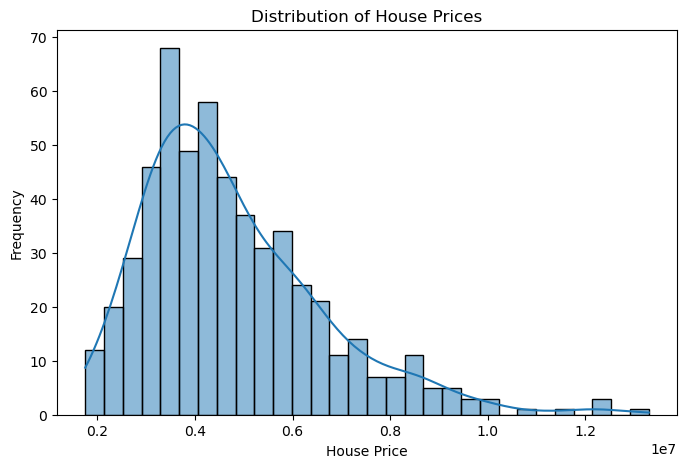

In [31]:
##1.Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')

plt.savefig('chart1_price_distribution.png')

plt.show()

Most houses in the dataset belong to the affordable and mid-range categories, while only a few premium properties significantly increase the overall price range.

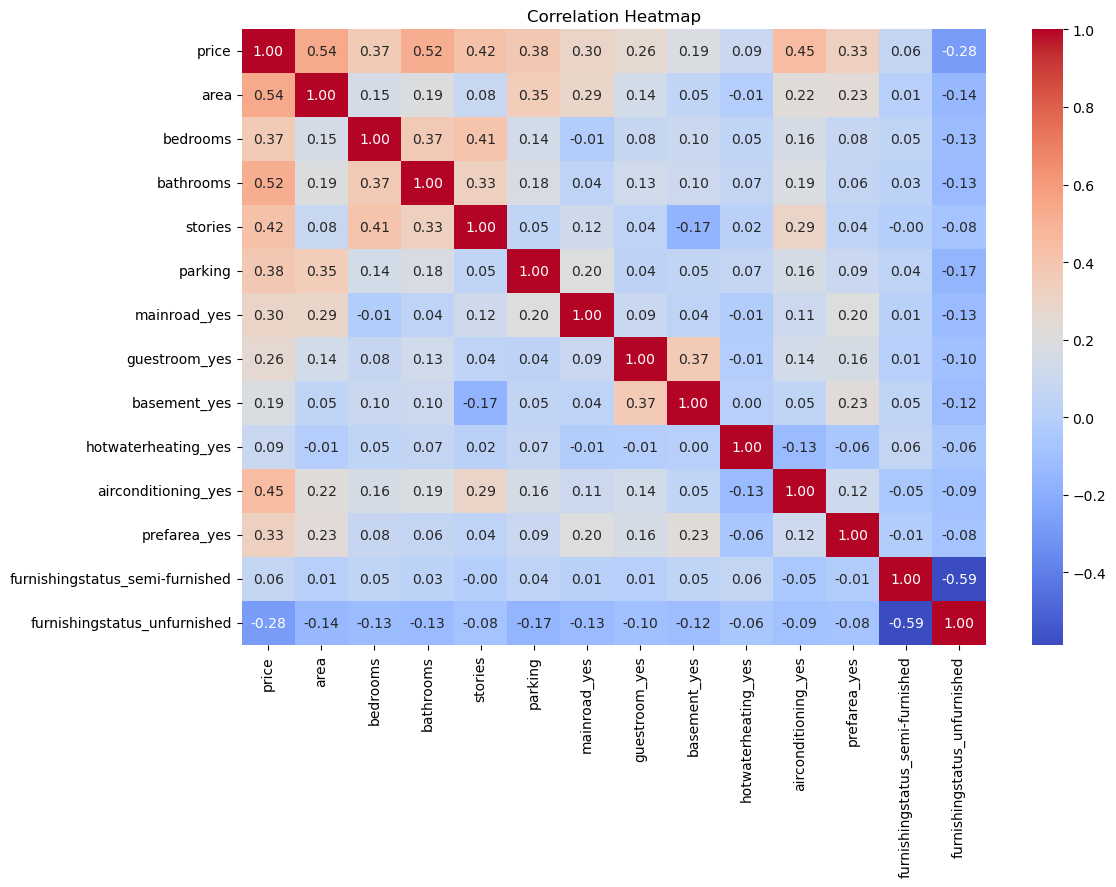

In [32]:
##COrrelation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig('chart2_correlation_heatmap.png')

plt.show()

Area, bathrooms, and air conditioning are the strongest factors influencing house prices.

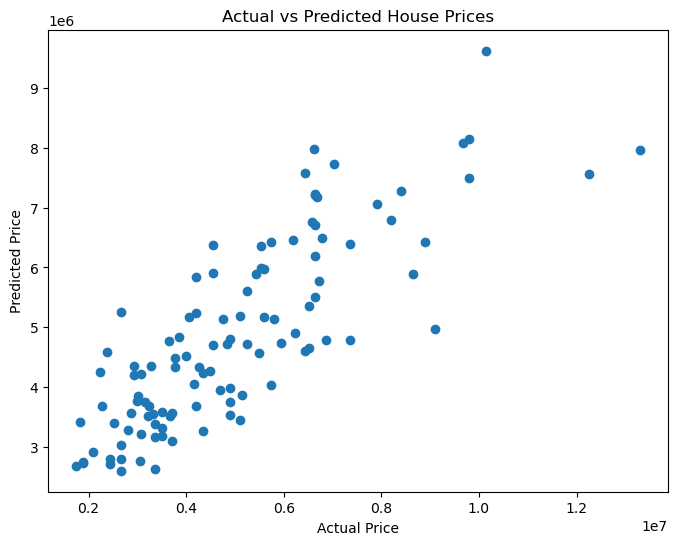

In [33]:
##Actual vs Predict house prices(linear regression)
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted House Prices')

plt.savefig('chart3_actual_vs_predicted.png')

plt.show()

The regression model successfully captures the relationship between house features and price, providing reasonably accurate predictions.

In [34]:
correlation_with_price = df_encoded.corr()['price'].sort_values(ascending=False)

print(correlation_with_price)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


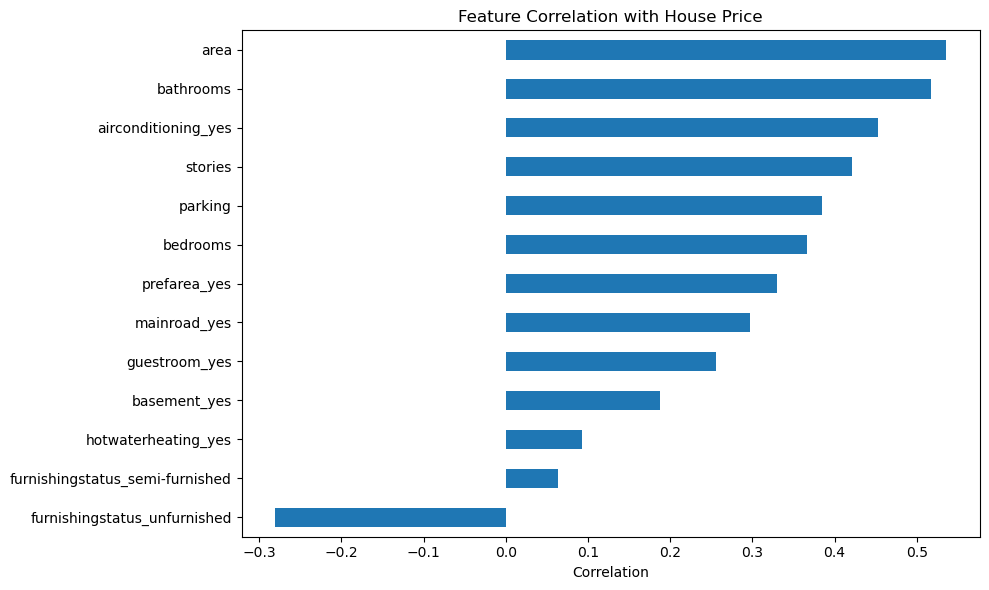

In [35]:
##Feature correlation with price
plt.figure(figsize=(10,6))

correlation_with_price.drop('price').sort_values().plot(kind='barh')

plt.title('Feature Correlation with House Price')

plt.xlabel('Correlation')

plt.tight_layout()

plt.savefig('chart4_feature_correlation.png')

plt.show()

The most important factor affecting house price is property area, followed by number of bathrooms and availability of air conditioning.

In [36]:
import os

print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.copilot', '.docker', '.eclipse', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.local', '.matplotlib', '.ms-ad', '.p2', '.streamlit', '.vscode', '.vscode-shared', 'Algerian_forest_fires_cleaned_dataset.csv', 'Algerian_forest_fires_dataset_UPDATE.csv', 'anaconda3', 'anaconda_projects', 'analysis.ipynb', 'app', 'app.py', 'AppData', 'Application Data', 'chart1_price_distribution.png', 'chart2_correlation_heatmap.png', 'chart2_heatmap.png', 'chart3_actual_vs_predicted.png', 'chart4_feature_correlation.png', 'Contacts', 'Cookies', 'dimention_reduction_pipelines_project.ipynb', 'DockerFile', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'Favorites', 'HousePricePrediction_Pranavika', 'HousePricePrediction_Pranavika (2).zip', 'Housing.csv', 'import java.util.java', 'IntelGraphicsProfiles', 'LinearRegressionTg.ipynb', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'New folder', '

In [37]:
correlation_with_price = df_encoded.corr()['price'].sort_values(ascending=False)

print(correlation_with_price)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


**INSIGHTS**

The House Price Prediction project was completed using Linear Regression and Random Forest Regression models. After comparing both models, Linear Regression performed better with an R² score of 0.653, indicating that the model explained approximately 65.3% of the variation in house prices. The most influential factors affecting house prices were area, number of bathrooms, air conditioning, number of stories, and parking availability. One interesting finding was that unfurnished houses showed a negative relationship with price, while houses with additional facilities such as air conditioning and parking were generally more expensive. The analysis suggests that property size and amenities play a major role in determining house value. Based on these findings, real estate businesses should focus on promoting larger properties with better facilities to maximize selling prices and attract buyers.


In [39]:
import os

print(os.getcwd())

C:\Users\DELL


In [40]:
import os
print(os.path.abspath("analysis.ipynb"))

C:\Users\DELL\analysis.ipynb
